# Week 13 Homework — ARIA v9.0: The Cloud Engine

**任務主題：** Cloud-Scale Vegetation Trend Analysis — Xiulin / Taroko Study Area（秀林／太魯閣研究區）  
**Notebook 目的：** 將作業整理成可執行版本，包含 Task 1–4 的程式碼、圖表、匯出設定，以及每一題的 Markdown 作答區。  

## 使用方式

1. 在 notebook 同一層建立 `.env` 檔案。
2. 將 `GEE_PROJECT_ID` 改成你的 Google Earth Engine Project ID。
3. 依序執行所有儲存格。
4. `RUN_EXPORTS=false` 時不會真的送出 Google Drive 匯出任務；確定要交作業前，再改成 `true` 並重跑 Task 4 匯出區塊。

> 注意：本 notebook 的數值答案會依據你實際執行 GEE 後自動計算，所以 Markdown 作答區採用「自動產生文字 + 可手動微調」的方式，避免填入未執行資料造成錯誤。

## 0. 安裝套件與讀取 `.env`

此區塊會讀取 `.env` 內的參數，例如 `GEE_PROJECT_ID`、研究區 BBOX、日期範圍、雲量門檻與匯出資料夾。  
如果 notebook 找不到 `.env`，會自動產生 `.env.example`，請複製成 `.env` 後填入自己的設定。

In [1]:
# ============================================================
# 0-1. 安裝與載入套件
# ============================================================
import sys
import subprocess
import importlib.util


def ensure_package(import_name, pip_name=None):
    """若套件尚未安裝，則自動 pip install。"""
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

# Colab 通常已有 numpy/pandas/matplotlib，但 geemap/dotenv 可能需要安裝
ensure_package("ee", "earthengine-api")
ensure_package("geemap", "geemap")
ensure_package("dotenv", "python-dotenv")
ensure_package("imageio", "imageio")
ensure_package("PIL", "pillow")

import os
import json
from pathlib import Path
from datetime import datetime

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display, Markdown

# Colab 互動地圖支援：若不是 Colab，這段會自動略過
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

print("Packages are ready.")

Installing imageio ...
Packages are ready.


In [25]:
# ============================================================
# 0-2. 建立 .env 範本並讀取參數
# ============================================================
ENV_PATH = Path(".env")
ENV_EXAMPLE_PATH = Path(".env.example")

ENV_TEMPLATE = """# Week 13 ARIA v9.0 — The Cloud Engine
# 請把此檔另存成 .env，並放在 notebook 同一層資料夾。

# 必填：你的 Google Earth Engine Cloud Project ID
GEE_PROJECT_ID=your-gee-project-id

# Study Area：Xiulin / Taroko BBOX，格式 west,south,east,north
TAROKO_BBOX=121.34526379253053,24.046021742135874,121.85149217685861,24.35767637905926

# Sentinel-2 NDVI 時序設定
S2_START=2020-01-01
S2_END=2026-03-31
CLOUDY_PIXEL_PERCENTAGE=40

# Sentinel-1 SAR 時序設定
S1_START=2022-01-01
S1_END=2026-03-31
S1_ORBIT=DESCENDING

# 分析與匯出設定
OUTPUT_DIR=outputs
EXPORT_FOLDER=GEE_Exports
CRS=EPSG:32651
SCALE=10
NDVI_LOSS_THRESHOLD=-0.15
VV_CHANGE_THRESHOLD=2

# 為了避免誤送出大量 Drive 匯出任務，預設 false。
# 確定要匯出 GeoTIFF 時，改成 true。
RUN_EXPORTS=false
"""

if not ENV_EXAMPLE_PATH.exists():
    ENV_EXAMPLE_PATH.write_text(ENV_TEMPLATE, encoding="utf-8")

if not ENV_PATH.exists():
    print("⚠️ 找不到 .env。已建立 .env.example。")
    print("請將 .env.example 複製成 .env，並填入你的 GEE_PROJECT_ID。")
    print("在 Colab 可用左側檔案面板上傳 .env，或執行下方指令建立。")
else:
    print("已找到 .env，準備讀取參數。")

load_dotenv(ENV_PATH, override=True)


def getenv_str(name, default=""):
    return os.getenv(name, default).strip()


def getenv_float(name, default):
    value = os.getenv(name, str(default)).strip()
    return float(value)


def getenv_int(name, default):
    value = os.getenv(name, str(default)).strip()
    return int(float(value))


def getenv_bool(name, default=False):
    value = os.getenv(name, str(default)).strip().lower()
    return value in {"1", "true", "yes", "y", "on"}


def parse_bbox(value):
    """支援 'west,south,east,north' 或 JSON list 格式。"""
    value = value.strip()
    if value.startswith("["):
        bbox = json.loads(value)
    else:
        bbox = [float(x.strip()) for x in value.split(",")]
    if len(bbox) != 4:
        raise ValueError("TAROKO_BBOX 必須有 4 個數值：west,south,east,north")
    return bbox

GEE_PROJECT_ID = getenv_str("GEE_PROJECT_ID", "your-gee-project-id")
TAROKO_BBOX = parse_bbox(getenv_str("TAROKO_BBOX", "121.34526379253053,24.046021742135874,121.85149217685861,24.35767637905926"))
S2_START = getenv_str("S2_START", "2020-01-01")
S2_END = getenv_str("S2_END", "2026-03-31")
S1_START = getenv_str("S1_START", "2022-01-01")
S1_END = getenv_str("S1_END", "2026-03-31")
S1_ORBIT = getenv_str("S1_ORBIT", "DESCENDING")
CLOUDY_PIXEL_PERCENTAGE = getenv_float("CLOUDY_PIXEL_PERCENTAGE", 40)
OUTPUT_DIR = Path(getenv_str("OUTPUT_DIR", "outputs"))
EXPORT_FOLDER = getenv_str("EXPORT_FOLDER", "GEE_Exports")
CRS = getenv_str("CRS", "EPSG:32651")
SCALE = getenv_int("SCALE", 10)
NDVI_LOSS_THRESHOLD = getenv_float("NDVI_LOSS_THRESHOLD", -0.15)
VV_CHANGE_THRESHOLD = getenv_float("VV_CHANGE_THRESHOLD", 2)
RUN_EXPORTS = getenv_bool("RUN_EXPORTS", False)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "GEE_PROJECT_ID": GEE_PROJECT_ID,
    "TAROKO_BBOX": TAROKO_BBOX,
    "S2_START": S2_START,
    "S2_END": S2_END,
    "S1_START": S1_START,
    "S1_END": S1_END,
    "S1_ORBIT": S1_ORBIT,
    "CLOUDY_PIXEL_PERCENTAGE": CLOUDY_PIXEL_PERCENTAGE,
    "OUTPUT_DIR": str(OUTPUT_DIR),
    "EXPORT_FOLDER": EXPORT_FOLDER,
    "CRS": CRS,
    "SCALE": SCALE,
    "NDVI_LOSS_THRESHOLD": NDVI_LOSS_THRESHOLD,
    "VV_CHANGE_THRESHOLD": VV_CHANGE_THRESHOLD,
    "RUN_EXPORTS": RUN_EXPORTS,
}

pd.DataFrame([config]).T.rename(columns={0: "value"})

已找到 .env，準備讀取參數。


,value
GEE_PROJECT_ID,aria-496806
TAROKO_BBOX,"[121.34526379253053, 24.046021742135874, 121.8..."
S2_START,2020-01-01
S2_END,2026-03-31
S1_START,2022-01-01
S1_END,2026-03-31
S1_ORBIT,DESCENDING
CLOUDY_PIXEL_PERCENTAGE,40.0
OUTPUT_DIR,outputs
EXPORT_FOLDER,GEE_Exports


In [6]:
# ============================================================
# 0-3. 初始化 Google Earth Engine
# ============================================================
if not GEE_PROJECT_ID or GEE_PROJECT_ID == "your-gee-project-id":
    raise ValueError(
        "請先在 .env 中設定 GEE_PROJECT_ID。\n"
        "範例：GEE_PROJECT_ID=my-earthengine-project"
    )

try:
    ee.Initialize(project=GEE_PROJECT_ID)
    print(f"Earth Engine initialized with project: {GEE_PROJECT_ID}")
except Exception as e:
    print("Earth Engine 尚未完成認證或初始化，準備啟動認證流程...")
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT_ID)
    print(f"Earth Engine initialized with project: {GEE_PROJECT_ID}")

aoi = ee.Geometry.Rectangle(TAROKO_BBOX)
center_lat = (TAROKO_BBOX[1] + TAROKO_BBOX[3]) / 2
center_lon = (TAROKO_BBOX[0] + TAROKO_BBOX[2]) / 2

print("Study area: Xiulin / Taroko")
print("BBOX:", TAROKO_BBOX)
print("Center:", center_lat, center_lon)

Earth Engine initialized with project: aria-496806
Study area: Xiulin / Taroko
BBOX: [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
Center: 24.201849060597567 121.59837798469457


## Task 1 — NDVI Time Series Analysis

**目標：** 使用 GEE 計算秀林／太魯閣研究區 2020–2026 年的月均 NDVI 時序，觀察植被季節變化、地震前後變化與缺值月份。  

本區塊會：

1. 篩選 Sentinel-2 L2A 影像。
2. 使用 SCL band 進行雲遮罩。
3. 計算 NDVI。
4. 逐月計算 AOI 平均 NDVI。
5. 繪製時序圖，並標示 2024/04/03 花蓮地震。

In [7]:
# ============================================================
# Task 1-1. Sentinel-2 篩選與 NDVI 計算
# ============================================================
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(S2_START, S2_END)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", CLOUDY_PIXEL_PERCENTAGE))
)

s2_count = s2.size().getInfo()
print(f"Total Sentinel-2 images: {s2_count}")


def mask_and_ndvi(image):
    """
    使用 Sentinel-2 Scene Classification Layer (SCL) 遮掉雲與雲影後計算 NDVI。
    SCL 保留類別：
    4 = vegetation, 5 = bare soils, 6 = water, 7 = unclassified
    """
    scl = image.select("SCL")
    good = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    masked = image.updateMask(good)
    ndvi = masked.normalizedDifference(["B8", "B4"]).rename("NDVI")
    return ndvi.copyProperties(image, ["system:time_start"])

ndvi_collection = s2.map(mask_and_ndvi)
print("NDVI collection is ready.")

Total Sentinel-2 images: 291
NDVI collection is ready.


In [8]:
# ============================================================
# Task 1-2. 月均 NDVI 時序表
# ============================================================
def month_range(start_date, end_date):
    """產生每月第一天，end_date 為分析結束日期，包含結束月份。"""
    start = pd.to_datetime(start_date).replace(day=1)
    end = pd.to_datetime(end_date).replace(day=1)
    return pd.date_range(start, end, freq="MS")

months = month_range(S2_START, S2_END)
records = []

for month_start in months:
    start_str = month_start.strftime("%Y-%m-%d")
    end_str = (month_start + pd.DateOffset(months=1)).strftime("%Y-%m-%d")
    monthly_coll = ndvi_collection.filterDate(start_str, end_str)
    count = monthly_coll.size().getInfo()

    if count == 0:
        mean_ndvi = np.nan
    else:
        img = monthly_coll.median()
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=30,          # 時序平均用 30m 加速；地圖與匯出仍用 10m
            maxPixels=1e9,
            bestEffort=True,
        ).getInfo()
        mean_ndvi = stats.get("NDVI", np.nan)

    records.append({
        "date": month_start,
        "month": month_start.strftime("%Y-%m"),
        "image_count": count,
        "mean_ndvi": mean_ndvi,
    })
    print(f"{month_start.strftime('%Y-%m')}: images={count}, mean_ndvi={mean_ndvi}")

ndvi_monthly_df = pd.DataFrame(records)
ndvi_monthly_csv = OUTPUT_DIR / "task1_monthly_ndvi_2020_2026.csv"
ndvi_monthly_df.to_csv(ndvi_monthly_csv, index=False, encoding="utf-8-sig")
print(f"Saved: {ndvi_monthly_csv}")
ndvi_monthly_df.head()

2020-01: images=8, mean_ndvi=0.4595180237596787
2020-02: images=4, mean_ndvi=0.46105951830890324
2020-03: images=5, mean_ndvi=0.43033547091987345
2020-04: images=2, mean_ndvi=0.4992986490181259
2020-05: images=4, mean_ndvi=0.43834946972661093
2020-06: images=5, mean_ndvi=0.5504583692255614
2020-07: images=5, mean_ndvi=0.5292347531617662
2020-08: images=4, mean_ndvi=0.5118675440523274
2020-09: images=5, mean_ndvi=0.4927676128528626
2020-10: images=3, mean_ndvi=0.48198682522595937
2020-11: images=5, mean_ndvi=0.49933874426247143
2020-12: images=2, mean_ndvi=0.3467006753198083
2021-01: images=6, mean_ndvi=0.49182843444398405
2021-02: images=6, mean_ndvi=0.4271264291987783
2021-03: images=6, mean_ndvi=0.4794802852955849
2021-04: images=4, mean_ndvi=0.4705243241995113
2021-05: images=5, mean_ndvi=0.5245281744302945
2021-06: images=2, mean_ndvi=0.6667488727818425
2021-07: images=6, mean_ndvi=0.5332221667666422
2021-08: images=3, mean_ndvi=0.48629122891926635
2021-09: images=10, mean_ndvi=0.4

,date,month,image_count,mean_ndvi
0,2020-01-01,2020-01,8,0.459518
1,2020-02-01,2020-02,4,0.461060
2,2020-03-01,2020-03,5,0.430335
3,2020-04-01,2020-04,2,0.499299
4,2020-05-01,2020-05,4,0.438349


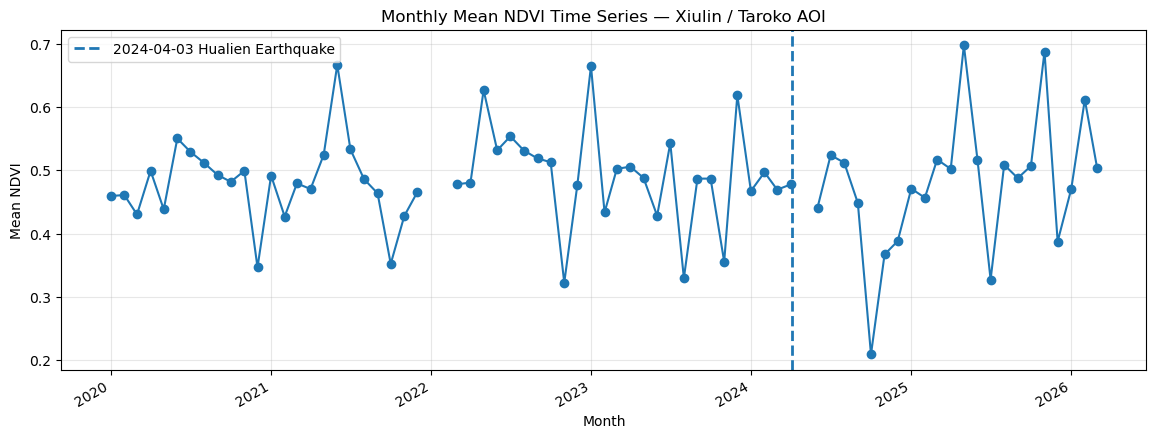

Saved: outputs\task1_ndvi_time_series.png


In [9]:
# ============================================================
# Task 1-3. 繪製 NDVI 時序圖
# ============================================================
earthquake_date = pd.to_datetime("2024-04-03")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ndvi_monthly_df["date"], ndvi_monthly_df["mean_ndvi"], marker="o", linewidth=1.5)
ax.axvline(earthquake_date, linestyle="--", linewidth=2, label="2024-04-03 Hualien Earthquake")
ax.set_title("Monthly Mean NDVI Time Series — Xiulin / Taroko AOI")
ax.set_xlabel("Month")
ax.set_ylabel("Mean NDVI")
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate()

plot_path = OUTPUT_DIR / "task1_ndvi_time_series.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved: {plot_path}")

In [10]:
# ============================================================
# Task 1-4. 自動產生 Task 1 Markdown 作答文字
# ============================================================
df = ndvi_monthly_df.copy()
valid_df = df.dropna(subset=["mean_ndvi"])
missing_months = df.loc[df["mean_ndvi"].isna() | (df["image_count"] == 0), "month"].tolist()

pre_window = valid_df[(valid_df["date"] >= "2023-01-01") & (valid_df["date"] <= "2024-03-31")]
post_window = valid_df[(valid_df["date"] >= "2024-04-01") & (valid_df["date"] <= "2024-09-30")]
recent_window = valid_df[(valid_df["date"] >= "2025-10-01") & (valid_df["date"] <= "2026-03-31")]

pre_mean = pre_window["mean_ndvi"].mean() if len(pre_window) else np.nan
post_mean = post_window["mean_ndvi"].mean() if len(post_window) else np.nan
recent_mean = recent_window["mean_ndvi"].mean() if len(recent_window) else np.nan
ndvi_drop = post_mean - pre_mean if np.isfinite(pre_mean) and np.isfinite(post_mean) else np.nan

monthly_climatology = valid_df.assign(m=valid_df["date"].dt.month).groupby("m")["mean_ndvi"].mean()
season_high = monthly_climatology.idxmax() if len(monthly_climatology) else None
season_low = monthly_climatology.idxmin() if len(monthly_climatology) else None

missing_text = "、".join(missing_months[:12]) + ("……" if len(missing_months) > 12 else "") if missing_months else "無明顯缺值月份"

if np.isfinite(ndvi_drop):
    if ndvi_drop < -0.03:
        eq_sentence = f"震後 2024/04–2024/09 的平均 NDVI 約為 {post_mean:.3f}，相較震前 2023/01–2024/03 的 {pre_mean:.3f} 下降約 {abs(ndvi_drop):.3f}，代表地震後植被狀態有可見降低。"
    elif ndvi_drop > 0.03:
        eq_sentence = f"震後 2024/04–2024/09 的平均 NDVI 約為 {post_mean:.3f}，相較震前 2023/01–2024/03 的 {pre_mean:.3f} 上升約 {ndvi_drop:.3f}；就整體 AOI 平均而言，地震影響可能被季節性、雲遮罩或未受災植被區域稀釋。"
    else:
        eq_sentence = f"震後 2024/04–2024/09 的平均 NDVI 約為 {post_mean:.3f}，與震前 2023/01–2024/03 的 {pre_mean:.3f} 差異約 {ndvi_drop:.3f}，整體 AOI 平均變化不大，但局部崩塌仍可能需要從 ΔNDVI map 判讀。"
else:
    eq_sentence = "因震前或震後視窗資料不足，本次月均 NDVI 無法穩定估計整體地震前後差異，需搭配 composite map 觀察空間變化。"

if season_high and season_low:
    seasonal_sentence = f"月均 NDVI 呈現季節性起伏，長期平均最高月份約為 {season_high} 月，最低月份約為 {season_low} 月，反映山區植被物候、降雨與雲遮罩共同造成的季節差異。"
else:
    seasonal_sentence = "因有效月份不足，季節性訊號不明顯。"

task1_answer = f"""
### Task 1 作答區：NDVI Time Series Analysis

本研究使用 Google Earth Engine 篩選 `COPERNICUS/S2_SR_HARMONIZED`，研究區為秀林／太魯閣 BBOX，時間範圍為 {S2_START} 至 {S2_END}，並以 `CLOUDY_PIXEL_PERCENTAGE < {CLOUDY_PIXEL_PERCENTAGE:g}` 進行初步影像篩選。接著使用 SCL band 保留 vegetation、bare soil、water 與 unclassified 類別，遮罩雲與低品質像元後計算 NDVI，最後以每月 median composite 估算 AOI 內月均 NDVI。

{seasonal_sentence} {eq_sentence} 缺值或資料品質較差的月份包含：{missing_text}。這些缺值主要可能來自花蓮山區的雲量、梅雨與颱風季造成的可用光學影像不足，因此在解讀時序曲線時，不能只看單一月份的高低，而應搭配多月 composite 與 SAR 資料進行交叉判讀。
"""

display(Markdown(task1_answer))


### Task 1 作答區：NDVI Time Series Analysis

本研究使用 Google Earth Engine 篩選 `COPERNICUS/S2_SR_HARMONIZED`，研究區為秀林／太魯閣 BBOX，時間範圍為 2020-01-01 至 2026-03-31，並以 `CLOUDY_PIXEL_PERCENTAGE < 40` 進行初步影像篩選。接著使用 SCL band 保留 vegetation、bare soil、water 與 unclassified 類別，遮罩雲與低品質像元後計算 NDVI，最後以每月 median composite 估算 AOI 內月均 NDVI。

月均 NDVI 呈現季節性起伏，長期平均最高月份約為 5 月，最低月份約為 10 月，反映山區植被物候、降雨與雲遮罩共同造成的季節差異。 震後 2024/04–2024/09 的平均 NDVI 約為 0.481，與震前 2023/01–2024/03 的 0.485 差異約 -0.004，整體 AOI 平均變化不大，但局部崩塌仍可能需要從 ΔNDVI map 判讀。 缺值或資料品質較差的月份包含：2022-01、2022-02、2024-05。這些缺值主要可能來自花蓮山區的雲量、梅雨與颱風季造成的可用光學影像不足，因此在解讀時序曲線時，不能只看單一月份的高低，而應搭配多月 composite 與 SAR 資料進行交叉判讀。


## Task 2 — Pre/Post Earthquake Median Composite

**目標：** 製作震前、震後與堰塞湖事件後三期 NDVI median composite，計算三組 ΔNDVI：

1. `delta_eq = post_eq - pre_eq`：地震前後變化。
2. `delta_dam = post_dam - post_eq`：堰塞湖事件後與地震後的差異。
3. `delta_total = post_dam - pre_eq`：震前到後期的總累積變化。

本區塊也會估算 `ΔNDVI < -0.15` 的植被損失面積，單位為 hectares。

In [11]:
# ============================================================
# Task 2-1. 三期 NDVI median composites 與 ΔNDVI
# ============================================================
pre_eq = ndvi_collection.filterDate("2023-01-01", "2024-04-01").median().clip(aoi).rename("NDVI_pre_eq")
post_eq = ndvi_collection.filterDate("2024-04-01", "2024-10-01").median().clip(aoi).rename("NDVI_post_eq")
post_dam = ndvi_collection.filterDate("2025-10-01", "2026-04-01").median().clip(aoi).rename("NDVI_post_dam")

delta_eq = post_eq.subtract(pre_eq).rename("delta_NDVI_eq")
delta_dam = post_dam.subtract(post_eq).rename("delta_NDVI_dam")
delta_total = post_dam.subtract(pre_eq).rename("delta_NDVI_total")

print("Composites and ΔNDVI images are ready.")

Composites and ΔNDVI images are ready.


In [12]:
# ============================================================
# Task 2-2. 計算 ΔNDVI < threshold 的面積
# ============================================================
def masked_area_ha(mask_image, geometry=aoi, scale=SCALE):
    """計算 boolean mask 為 True 的面積，單位 hectares。"""
    area_img = ee.Image.pixelArea().updateMask(mask_image)
    stats = area_img.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=geometry,
        scale=scale,
        maxPixels=1e10,
        bestEffort=True,
    ).getInfo()
    area_m2 = stats.get("area", 0) or 0
    return area_m2 / 10000

loss_eq = delta_eq.lt(NDVI_LOSS_THRESHOLD)
loss_dam = delta_dam.lt(NDVI_LOSS_THRESHOLD)
loss_total = delta_total.lt(NDVI_LOSS_THRESHOLD)

area_eq_ha = masked_area_ha(loss_eq)
area_dam_ha = masked_area_ha(loss_dam)
area_total_ha = masked_area_ha(loss_total)

area_df = pd.DataFrame({
    "phase": ["Earthquake impact: post_eq - pre_eq", "Post-dam change: post_dam - post_eq", "Total change: post_dam - pre_eq"],
    "threshold": [NDVI_LOSS_THRESHOLD] * 3,
    "loss_area_ha": [area_eq_ha, area_dam_ha, area_total_ha],
})
area_csv = OUTPUT_DIR / "task2_delta_ndvi_loss_area.csv"
area_df.to_csv(area_csv, index=False, encoding="utf-8-sig")
print(f"Saved: {area_csv}")
area_df

Saved: outputs\task2_delta_ndvi_loss_area.csv


,phase,threshold,loss_area_ha
0,Earthquake impact: post_eq - pre_eq,-0.15,7740.145333
1,Post-dam change: post_dam - post_eq,-0.15,6257.677281
2,Total change: post_dam - pre_eq,-0.15,6839.039621


In [14]:
# ============================================================
# Task 2-3. 互動地圖：三期 NDVI 與三組 ΔNDVI
# ============================================================
ndvi_vis = {
    "min": 0,
    "max": 0.8,
    "palette": ["brown", "yellow", "green", "darkgreen"],
}

delta_vis = {
    "min": -0.4,
    "max": 0.4,
    "palette": ["red", "white", "blue"],  # red = loss, blue = gain
}

Map2 = geemap.Map(center=[center_lat, center_lon], zoom=10)
Map2.add_basemap("HYBRID")
Map2.addLayer(pre_eq, ndvi_vis, "NDVI pre-earthquake median: 2023/01–2024/03", shown=False)
Map2.addLayer(post_eq, ndvi_vis, "NDVI post-earthquake median: 2024/04–2024/09", shown=True)
Map2.addLayer(post_dam, ndvi_vis, "NDVI post-dam median: 2025/10–2026/03", shown=False)
Map2.addLayer(delta_eq, delta_vis, "ΔNDVI earthquake: post_eq - pre_eq", shown=True)
Map2.addLayer(delta_dam, delta_vis, "ΔNDVI dam: post_dam - post_eq", shown=False)
Map2.addLayer(delta_total, delta_vis, "ΔNDVI total: post_dam - pre_eq", shown=False)
Map2.addLayer(aoi, {}, "AOI", shown=True)
Map2.addLayerControl()

html_path = OUTPUT_DIR / "task2_ndvi_composite_delta_map.html"
try:
    Map2.to_html(str(html_path))
    print(f"Interactive map saved: {html_path}")
except Exception as e:
    print("Map HTML export failed, but interactive map may still display below.", e)

Map2

Interactive map saved: outputs\task2_ndvi_composite_delta_map.html


Map(center=[24.201849060597567, 121.59837798469457], controls=(WidgetControl(options=['position', 'transparent…

In [15]:
# ============================================================
# Task 2-4. 自動產生 Task 2 Markdown 作答文字
# ============================================================
def interpret_area(area):
    if area > 1000:
        return "範圍相當大，顯示此階段在 AOI 內可能有廣泛植被損失或低 NDVI 區域。"
    elif area > 100:
        return "範圍中等，顯示此階段有明顯但較局部的植被損失。"
    elif area > 0:
        return "範圍較小，代表損失可能集中於局部崩塌、河谷或裸露地。"
    else:
        return "未偵測到符合門檻的植被損失區域，可能需要調整門檻或檢查資料品質。"

if area_eq_ha >= area_dam_ha:
    phase_compare = "地震前後的 ΔNDVI 損失面積大於或接近堰塞湖事件後的新增變化，表示 2024/04/03 地震可能是較主要的植被擾動來源。"
else:
    phase_compare = "堰塞湖事件後的 ΔNDVI 損失面積大於地震前後變化，表示後續水文或坡地擾動可能在部分區域造成新的植被損失。"

if area_total_ha < area_eq_ha:
    recovery_sentence = "總累積損失面積小於地震階段損失面積，可能代表部分震後受損區域在 2025–2026 間已有 NDVI 回升或植被恢復。"
else:
    recovery_sentence = "總累積損失面積仍然高於或接近地震階段損失面積，代表部分受損區域可能尚未完全恢復，或後續事件又造成新的低 NDVI 區域。"

task2_answer = f"""
### Task 2 作答區：Pre/Post Earthquake Median Composite

本題以 GEE 將 NDVI collection 分成三個時間階段：震前期（2023/01–2024/03）、震後期（2024/04–2024/09）與堰塞湖事件後期（2025/10–2026/03），並分別建立 median composite。相較於只選取單一影像，median composite 能降低單景雲、陰影、影像品質與短期異常值的影響，較適合山區長期變遷判讀。

以 `ΔNDVI < {NDVI_LOSS_THRESHOLD}` 作為植被損失門檻，本次估計地震前後損失面積約為 **{area_eq_ha:.2f} ha**，堰塞湖事件後新增變化面積約為 **{area_dam_ha:.2f} ha**，震前至後期的總累積損失面積約為 **{area_total_ha:.2f} ha**。地震階段：{interpret_area(area_eq_ha)} 堰塞湖後期：{interpret_area(area_dam_ha)} {phase_compare} {recovery_sentence}

與 W9 的兩期單景差值法相比，W13 的 composite-based change detection 較可靠，因為 W9 只要震前或震後其中一張影像受到雲、陰影或季節差異影響，就可能造成誤判；W13 則使用多張影像的中位數代表一段時間的典型狀態，可以降低單景影像的不穩定性。此外，三期比較能將地震、堰塞湖事件與後續恢復拆開來看，使災害時間線從單一「快照」轉為較完整的變化故事。
"""

display(Markdown(task2_answer))


### Task 2 作答區：Pre/Post Earthquake Median Composite

本題以 GEE 將 NDVI collection 分成三個時間階段：震前期（2023/01–2024/03）、震後期（2024/04–2024/09）與堰塞湖事件後期（2025/10–2026/03），並分別建立 median composite。相較於只選取單一影像，median composite 能降低單景雲、陰影、影像品質與短期異常值的影響，較適合山區長期變遷判讀。

以 `ΔNDVI < -0.15` 作為植被損失門檻，本次估計地震前後損失面積約為 **7740.15 ha**，堰塞湖事件後新增變化面積約為 **6257.68 ha**，震前至後期的總累積損失面積約為 **6839.04 ha**。地震階段：範圍相當大，顯示此階段在 AOI 內可能有廣泛植被損失或低 NDVI 區域。 堰塞湖後期：範圍相當大，顯示此階段在 AOI 內可能有廣泛植被損失或低 NDVI 區域。 地震前後的 ΔNDVI 損失面積大於或接近堰塞湖事件後的新增變化，表示 2024/04/03 地震可能是較主要的植被擾動來源。 總累積損失面積小於地震階段損失面積，可能代表部分震後受損區域在 2025–2026 間已有 NDVI 回升或植被恢復。

與 W9 的兩期單景差值法相比，W13 的 composite-based change detection 較可靠，因為 W9 只要震前或震後其中一張影像受到雲、陰影或季節差異影響，就可能造成誤判；W13 則使用多張影像的中位數代表一段時間的典型狀態，可以降低單景影像的不穩定性。此外，三期比較能將地震、堰塞湖事件與後續恢復拆開來看，使災害時間線從單一「快照」轉為較完整的變化故事。


## Task 3 — Sentinel-1 SAR Time Series

**目標：** 使用 Sentinel-1 GRD 的 VV polarization 分析地震前後地表散射變化，並與 NDVI 損失區域交叉比對。

本區塊會：

1. 篩選 Sentinel-1 GRD、IW mode、指定軌道方向、VV polarization。
2. 計算每張影像在 AOI 內的平均 VV backscatter。
3. 繪製 2022–2026 VV 時序圖。
4. 建立震前／震後 VV composite 與 ΔVV map。
5. 計算 `ΔNDVI < -0.15` 且 `|ΔVV| > 2 dB` 的高信心變化區域。

In [16]:
# ============================================================
# Task 3-1. Sentinel-1 GRD 篩選
# ============================================================
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filterDate(S1_START, S1_END)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", S1_ORBIT))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .select("VV")
)

s1_count = s1.size().getInfo()
print(f"Total Sentinel-1 images: {s1_count}")

Total Sentinel-1 images: 146


In [17]:
# ============================================================
# Task 3-2. VV 時序表
# ============================================================
def s1_image_to_feature(image):
    mean_vv = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        bestEffort=True,
    ).get("VV")
    return ee.Feature(None, {
        "date": ee.Date(image.get("system:time_start")).format("YYYY-MM-dd"),
        "mean_vv": mean_vv,
    })

s1_fc = ee.FeatureCollection(s1.map(s1_image_to_feature))
s1_info = s1_fc.getInfo()
s1_records = [f["properties"] for f in s1_info["features"]]
s1_df = pd.DataFrame(s1_records)
s1_df["date"] = pd.to_datetime(s1_df["date"])
s1_df["mean_vv"] = pd.to_numeric(s1_df["mean_vv"], errors="coerce")
s1_df = s1_df.sort_values("date").reset_index(drop=True)

s1_csv = OUTPUT_DIR / "task3_sentinel1_vv_time_series.csv"
s1_df.to_csv(s1_csv, index=False, encoding="utf-8-sig")
print(f"Saved: {s1_csv}")
s1_df.head()

Saved: outputs\task3_sentinel1_vv_time_series.csv


,date,mean_vv
0,2022-01-03,-10.087723
1,2022-02-08,-10.255667
2,2022-07-26,-11.385171
3,2022-08-07,-10.010176
4,2022-08-19,-10.871784


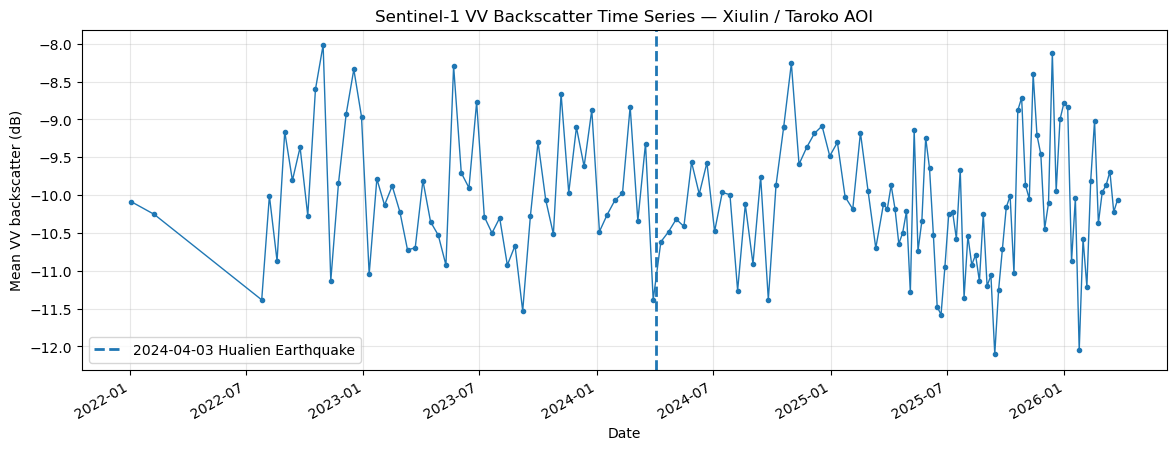

Saved: outputs\task3_s1_vv_time_series.png


In [18]:
# ============================================================
# Task 3-3. 繪製 Sentinel-1 VV 時序圖
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(s1_df["date"], s1_df["mean_vv"], marker=".", linestyle="-", linewidth=1)
ax.axvline(pd.to_datetime("2024-04-03"), linestyle="--", linewidth=2, label="2024-04-03 Hualien Earthquake")
ax.set_title("Sentinel-1 VV Backscatter Time Series — Xiulin / Taroko AOI")
ax.set_xlabel("Date")
ax.set_ylabel("Mean VV backscatter (dB)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.autofmt_xdate()

vv_plot_path = OUTPUT_DIR / "task3_s1_vv_time_series.png"
plt.savefig(vv_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {vv_plot_path}")

In [19]:
# ============================================================
# Task 3-4. VV pre/post composite、ΔVV 與高信心變化區
# ============================================================
pre_vv = s1.filterDate("2023-01-01", "2024-04-01").median().clip(aoi).rename("VV_pre")
post_vv = s1.filterDate("2024-04-01", "2026-04-01").median().clip(aoi).rename("VV_post")
delta_vv = post_vv.subtract(pre_vv).rename("delta_VV")

# 高信心變化：NDVI 顯著下降 + SAR backscatter 顯著改變
high_conf_change = delta_eq.lt(NDVI_LOSS_THRESHOLD).And(delta_vv.abs().gt(VV_CHANGE_THRESHOLD)).rename("high_conf_change")
high_conf_area_ha = masked_area_ha(high_conf_change)

print(f"High-confidence change area: {high_conf_area_ha:.2f} ha")

High-confidence change area: 537.37 ha


In [20]:
# ============================================================
# Task 3-5. ΔVV 與高信心變化區互動地圖
# ============================================================
vv_vis = {"min": -20, "max": 0}
delta_vv_vis = {"min": -5, "max": 5, "palette": ["purple", "white", "orange"]}
high_conf_vis = {"min": 0, "max": 1, "palette": ["000000", "ff0000"]}

Map3 = geemap.Map(center=[center_lat, center_lon], zoom=10)
Map3.add_basemap("HYBRID")
Map3.addLayer(pre_vv, vv_vis, "VV pre-earthquake median", shown=False)
Map3.addLayer(post_vv, vv_vis, "VV post-earthquake median", shown=False)
Map3.addLayer(delta_vv, delta_vv_vis, "ΔVV: post - pre", shown=True)
Map3.addLayer(delta_eq, delta_vis, "ΔNDVI earthquake", shown=False)
Map3.addLayer(high_conf_change.selfMask(), {"palette": ["red"]}, "High-confidence: ΔNDVI loss + |ΔVV| change", shown=True)
Map3.addLayer(aoi, {}, "AOI", shown=True)
Map3.addLayerControl()

html_path3 = OUTPUT_DIR / "task3_sar_delta_vv_high_conf_map.html"
try:
    Map3.to_html(str(html_path3))
    print(f"Interactive map saved: {html_path3}")
except Exception as e:
    print("Map HTML export failed, but interactive map may still display below.", e)

Map3

Interactive map saved: outputs\task3_sar_delta_vv_high_conf_map.html


Map(center=[24.201849060597567, 121.59837798469457], controls=(WidgetControl(options=['position', 'transparent…

In [21]:
# ============================================================
# Task 3-6. 自動產生 Task 3 Markdown 作答文字
# ============================================================
pre_vv_mean = s1_df[(s1_df["date"] >= "2023-01-01") & (s1_df["date"] <= "2024-03-31")]["mean_vv"].mean()
post_vv_mean = s1_df[(s1_df["date"] >= "2024-04-01") & (s1_df["date"] <= "2026-03-31")]["mean_vv"].mean()
vv_change = post_vv_mean - pre_vv_mean if np.isfinite(pre_vv_mean) and np.isfinite(post_vv_mean) else np.nan

if np.isfinite(vv_change):
    if vv_change > 0.5:
        vv_sentence = f"震後平均 VV 約為 {post_vv_mean:.2f} dB，較震前 {pre_vv_mean:.2f} dB 上升約 {vv_change:.2f} dB，可能表示裸露地、粗糙地表或散射條件增加。"
    elif vv_change < -0.5:
        vv_sentence = f"震後平均 VV 約為 {post_vv_mean:.2f} dB，較震前 {pre_vv_mean:.2f} dB 下降約 {abs(vv_change):.2f} dB，可能與地表變平滑、水體／濕潤區增加，或坡地散射幾何改變有關。"
    else:
        vv_sentence = f"震後平均 VV 約為 {post_vv_mean:.2f} dB，與震前 {pre_vv_mean:.2f} dB 差異約 {vv_change:.2f} dB，整體 AOI 平均變化不大，較可能需要從局部 ΔVV map 判讀。"
else:
    vv_sentence = "因 Sentinel-1 時序資料不足或統計值缺失，無法穩定估算震前震後平均 VV 差異。"

task3_answer = f"""
### Task 3 作答區：Sentinel-1 SAR Time Series

本題使用 `COPERNICUS/S1_GRD` 進行 SAR 時序分析，篩選條件包含研究區、{S1_START} 至 {S1_END}、IW mode、{S1_ORBIT} orbit，以及 VV polarization。Sentinel-1 的優勢是可穿透雲層，因此能補足 Sentinel-2 在山區多雲月份的限制，特別適合用來檢查地震後裸露地、河道、水體或坡面粗糙度變化。

{vv_sentence} 在空間上，若同一區域同時滿足 `ΔNDVI < {NDVI_LOSS_THRESHOLD}` 與 `|ΔVV| > {VV_CHANGE_THRESHOLD} dB`，本 notebook 將其視為高信心變化區，估計面積約為 **{high_conf_area_ha:.2f} ha**。這種交叉比對延續 W10 的 multi-source validation 概念：NDVI 可指出植被減少，SAR 則提供地表散射或濕潤度變化的獨立證據；兩者重疊時，比單一資料源更有利於判斷災後真實地表變化。
"""

display(Markdown(task3_answer))


### Task 3 作答區：Sentinel-1 SAR Time Series

本題使用 `COPERNICUS/S1_GRD` 進行 SAR 時序分析，篩選條件包含研究區、2022-01-01 至 2026-03-31、IW mode、DESCENDING orbit，以及 VV polarization。Sentinel-1 的優勢是可穿透雲層，因此能補足 Sentinel-2 在山區多雲月份的限制，特別適合用來檢查地震後裸露地、河道、水體或坡面粗糙度變化。

震後平均 VV 約為 -10.12 dB，與震前 -10.05 dB 差異約 -0.06 dB，整體 AOI 平均變化不大，較可能需要從局部 ΔVV map 判讀。 在空間上，若同一區域同時滿足 `ΔNDVI < -0.15` 與 `|ΔVV| > 2.0 dB`，本 notebook 將其視為高信心變化區，估計面積約為 **537.37 ha**。這種交叉比對延續 W10 的 multi-source validation 概念：NDVI 可指出植被減少，SAR 則提供地表散射或濕潤度變化的獨立證據；兩者重疊時，比單一資料源更有利於判斷災後真實地表變化。


## Task 4 — Export GeoTIFF + Integration Summary

**目標：** 將 GEE 分析結果匯出為 GeoTIFF，並撰寫 ARIA v9.0 升級整合摘要。  

本 notebook 預設 `RUN_EXPORTS=false`，避免你一跑就送出 Drive 匯出任務。  
要正式匯出時，請在 `.env` 改成：

```text
RUN_EXPORTS=true
```

至少會匯出兩個產品：

1. `taroko_ndvi_post_eq_2024`：震後 NDVI composite。
2. `taroko_delta_ndvi_eq_2024`：地震前後 ΔNDVI map。

In [26]:
# ============================================================
# Task 4-1. 匯出 GeoTIFF 到 Google Drive
# ============================================================
def start_drive_export(image, description, folder=EXPORT_FOLDER, region=aoi, scale=SCALE, crs=CRS):
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=description,
        folder=folder,
        fileNamePrefix=description,
        region=region,
        scale=scale,
        crs=crs,
        maxPixels=1e10,
    )
    task.start()
    return task

export_tasks = []

if RUN_EXPORTS:
    export_tasks.append(start_drive_export(post_eq.rename("NDVI"), "taroko_ndvi_post_eq_2024"))
    export_tasks.append(start_drive_export(delta_eq.rename("delta_NDVI"), "taroko_delta_ndvi_eq_2024"))
    # 額外匯出，方便後續 W12 Random Forest 或 GIS 疊圖
    export_tasks.append(start_drive_export(delta_total.rename("delta_NDVI_total"), "taroko_delta_ndvi_total_2026"))
    export_tasks.append(start_drive_export(high_conf_change.rename("high_conf_change"), "taroko_high_conf_ndvi_sar_change"))

    print("Export tasks started. Check Google Drive folder:", EXPORT_FOLDER)
    for t in export_tasks:
        print(t.id, t.status())
else:
    print("RUN_EXPORTS=false：目前不會送出 Drive 匯出任務。")
    print("確認要匯出 GeoTIFF 時，請在 .env 設定 RUN_EXPORTS=true，然後重跑此儲存格。")
    print("預計匯出產品：")
    print("1. taroko_ndvi_post_eq_2024.tif")
    print("2. taroko_delta_ndvi_eq_2024.tif")
    print("3. taroko_delta_ndvi_total_2026.tif（額外）")
    print("4. taroko_high_conf_ndvi_sar_change.tif（額外）")

Export tasks started. Check Google Drive folder: GEE_Exports
PZIBF5DWPSMM4XW3G7OCBDEQ {'state': 'RUNNING', 'description': 'taroko_ndvi_post_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779685478487, 'update_timestamp_ms': 1779685480653, 'start_timestamp_ms': 1779685480595, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'id': 'PZIBF5DWPSMM4XW3G7OCBDEQ', 'name': 'projects/aria-496806/operations/PZIBF5DWPSMM4XW3G7OCBDEQ'}
WXS3WAXT6VWZZXUBLXQKPEG4 {'state': 'RUNNING', 'description': 'taroko_delta_ndvi_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779685479045, 'update_timestamp_ms': 1779685480651, 'start_timestamp_ms': 1779685480588, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'id': 'WXS3WAXT6VWZZXUBLXQKPEG4', 'name': 'projects/aria-496806/operations/WXS3WAXT6VWZZXUBLXQKPEG4'}
T253HQ2FIPAI7TCJXTURUTIW {'state': 'READY', 'description': 'taroko_delta_ndvi_total_2026', 'priority': 100, 'creation_timestamp_ms': 1779685480491, 'update_timestamp_ms': 1779685480491, 'start_timestamp_ms'

In [27]:
# ============================================================
# Task 4-2. 檢查匯出任務狀態
# ============================================================
if export_tasks:
    for t in export_tasks:
        print(t.id, t.status())
else:
    print("目前沒有正在追蹤的 export_tasks。若已在 GEE Code Editor 或其他 notebook 匯出，請直接到 Google Drive 確認檔案。")

PZIBF5DWPSMM4XW3G7OCBDEQ {'state': 'RUNNING', 'description': 'taroko_ndvi_post_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779685478487, 'update_timestamp_ms': 1779685480653, 'start_timestamp_ms': 1779685480595, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'id': 'PZIBF5DWPSMM4XW3G7OCBDEQ', 'name': 'projects/aria-496806/operations/PZIBF5DWPSMM4XW3G7OCBDEQ'}
WXS3WAXT6VWZZXUBLXQKPEG4 {'state': 'RUNNING', 'description': 'taroko_delta_ndvi_eq_2024', 'priority': 100, 'creation_timestamp_ms': 1779685479045, 'update_timestamp_ms': 1779685480651, 'start_timestamp_ms': 1779685480588, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'id': 'WXS3WAXT6VWZZXUBLXQKPEG4', 'name': 'projects/aria-496806/operations/WXS3WAXT6VWZZXUBLXQKPEG4'}
T253HQ2FIPAI7TCJXTURUTIW {'state': 'RUNNING', 'description': 'taroko_delta_ndvi_total_2026', 'priority': 100, 'creation_timestamp_ms': 1779685480491, 'update_timestamp_ms': 1779685485254, 'start_timestamp_ms': 1779685485193, 'task_type': 'EXPORT_IMAGE', 'attempt': 1,

In [28]:
# ============================================================
# Task 4-3. 自動產生 300–500 字 Integration Summary
# ============================================================
# 粗略估算本機下載與處理時間：
# 這只是作業報告用的合理估計，不是實測值。
local_min_low = s2_count * 1.0 + s1_count * 0.5
local_min_high = s2_count * 3.0 + s1_count * 1.5

local_time_sentence = (
    f"若改成本機逐張下載與處理，假設每張 Sentinel-2 需要 1–3 分鐘、每張 Sentinel-1 需要 0.5–1.5 分鐘，"
    f"總處理時間可能約為 {local_min_low/60:.1f}–{local_min_high/60:.1f} 小時，且尚未包含資料下載失敗、重投影、裁切與硬碟空間管理成本。"
)

summary = f"""
### Task 4 作答區：ARIA v9.0 Integration Summary

本次 ARIA v9.0 將分析尺度從 W8–W12 的單景或少量影像，提升到 Google Earth Engine 的雲端時序分析。本 notebook 在秀林／太魯閣研究區共篩選並處理 **{s2_count} 張 Sentinel-2 L2A 影像**與 **{s1_count} 張 Sentinel-1 GRD 影像**。{local_time_sentence} 因此，GEE 的核心價值不只是節省時間，也在於能快速完成 ImageCollection 篩選、雲遮罩、Reducer 統計、median composite 與大範圍匯出。

NDVI 時序結果顯示，太魯閣山區的植被指數具有季節性起伏，部分月份因山區雲量、梅雨或颱風季而出現缺值或資料品質較差。震前至震後的 composite 比較中，以 `ΔNDVI < {NDVI_LOSS_THRESHOLD}` 作為植被損失門檻，地震階段損失面積約為 **{area_eq_ha:.2f} ha**，堰塞湖事件後新增損失約為 **{area_dam_ha:.2f} ha**，總累積損失約為 **{area_total_ha:.2f} ha**。這表示時序分析能將不同災害階段拆開，而不只是看到單一時間點的變化。

跨週整合上，GEE 時序分析改善了 W8 單景 NDVI 容易受雲與日期影響的問題；median composite 也比 W9 的兩景差值更穩定，能降低單張影像異常造成的誤判。Task 3 的 Sentinel-1 VV 時序則延伸 W10 的 SAR 穿雲概念，提供光學資料之外的地表散射變化證據。若將本次匯出的 post-earthquake NDVI 或 ΔNDVI GeoTIFF 餵入 W12 Random Forest classifier，預期可把「分類結果」與「變化強度」結合，進一步區分穩定森林、震後裸露地、河道／水體與可能恢復區域。

限制方面，GEE 雖然適合快速雲端分析，但對客製化本機演算法、精細檔案管理、特殊模型訓練流程與大型中間結果除錯較不彈性。因此當研究需要完整掌控每個像元處理流程、使用本機機器學習模型、或整合大量非 GEE 資料時，仍會選擇 W8–W12 的 STAC API 加本機處理流程。
"""

display(Markdown(summary))

summary_path = OUTPUT_DIR / "task4_integration_summary.md"
summary_path.write_text(summary, encoding="utf-8")
print(f"Saved: {summary_path}")


### Task 4 作答區：ARIA v9.0 Integration Summary

本次 ARIA v9.0 將分析尺度從 W8–W12 的單景或少量影像，提升到 Google Earth Engine 的雲端時序分析。本 notebook 在秀林／太魯閣研究區共篩選並處理 **291 張 Sentinel-2 L2A 影像**與 **146 張 Sentinel-1 GRD 影像**。若改成本機逐張下載與處理，假設每張 Sentinel-2 需要 1–3 分鐘、每張 Sentinel-1 需要 0.5–1.5 分鐘，總處理時間可能約為 6.1–18.2 小時，且尚未包含資料下載失敗、重投影、裁切與硬碟空間管理成本。 因此，GEE 的核心價值不只是節省時間，也在於能快速完成 ImageCollection 篩選、雲遮罩、Reducer 統計、median composite 與大範圍匯出。

NDVI 時序結果顯示，太魯閣山區的植被指數具有季節性起伏，部分月份因山區雲量、梅雨或颱風季而出現缺值或資料品質較差。震前至震後的 composite 比較中，以 `ΔNDVI < -0.15` 作為植被損失門檻，地震階段損失面積約為 **7740.15 ha**，堰塞湖事件後新增損失約為 **6257.68 ha**，總累積損失約為 **6839.04 ha**。這表示時序分析能將不同災害階段拆開，而不只是看到單一時間點的變化。

跨週整合上，GEE 時序分析改善了 W8 單景 NDVI 容易受雲與日期影響的問題；median composite 也比 W9 的兩景差值更穩定，能降低單張影像異常造成的誤判。Task 3 的 Sentinel-1 VV 時序則延伸 W10 的 SAR 穿雲概念，提供光學資料之外的地表散射變化證據。若將本次匯出的 post-earthquake NDVI 或 ΔNDVI GeoTIFF 餵入 W12 Random Forest classifier，預期可把「分類結果」與「變化強度」結合，進一步區分穩定森林、震後裸露地、河道／水體與可能恢復區域。

限制方面，GEE 雖然適合快速雲端分析，但對客製化本機演算法、精細檔案管理、特殊模型訓練流程與大型中間結果除錯較不彈性。因此當研究需要完整掌控每個像元處理流程、使用本機機器學習模型、或整合大量非 GEE 資料時，仍會選擇 W8–W12 的 STAC API 加本機處理流程。


Saved: outputs\task4_integration_summary.md


## Bonus 1 — InSAR Interferogram Reading Exercise

以下答案依據作業指定的「InSAR 彩虹干涉環判讀」文章中 2016 熊本地震圖 3 的判讀流程撰寫。  
作業若不做加分題，可略過此區。

### Bonus 1 作答區：InSAR 干涉圖判讀

1. **衛星資訊：** 該干涉圖使用 ALOS-2 衛星，為 L 波段雷達影像，波長約 **23.6 公分**。影像使用主震前 2016/04/15 與主震後 2016/04/29 的資料，屬於下降軌、左視觀測。

2. **每環位移量：** 每一個完整干涉環代表半個波長的 LOS 位移，因此約為 **23.6 ÷ 2 = 11.8 公分**，作答時可寫約 **12 公分**。

3. **干涉環數量：** 斷層上方區域由外圍不動點往變形中心估算，約有 **15–17 個完整干涉環**。

4. **位移方向：** 圖例中「藍 → 黃 → 紫」代表接近衛星，「藍 → 紫 → 黃」代表遠離衛星。熊本地震圖 3 斷層上方區域主要呈現 **藍 → 紫 → 黃**，因此代表 **遠離衛星方向** 的 LOS 位移。

5. **總位移量估算：** 每環約 12 公分，乘上 15–17 環，可估算 LOS 位移約為 **180–204 公分**。這是視線方向位移，並不等於完整三維地表位移，但量級上可反映強烈地表變形。

**簡短心得：**  
InSAR 干涉圖能提供 SAR 振幅分析做不到的「位移量」與「位移方向」資訊。W10 的 SAR backscatter 主要判斷地表粗糙度、水體或裸露地變化，但無法直接知道地表往哪裡移動、移動多少。InSAR 則利用相位差推估 LOS 方向變形，因此特別適合地震、火山、地層下陷與大規模坡地變形監測。

## Bonus 2 — NDVI Time-Lapse Animation

**目標：** 建立 2020–2026 半年度 NDVI GIF，呈現太魯閣／秀林地區植被變化歷程。  
此加分題會使用 `getThumbURL()` 取得 GEE 縮圖，再用 `PIL` 加上時間標籤，最後輸出 GIF。

In [29]:
# ============================================================
# Bonus 2-1. 建立 NDVI time-lapse GIF
# ============================================================
import io
import requests
from PIL import Image, ImageDraw, ImageFont
import imageio.v2 as imageio

periods = [
    ("2020-H1", "2020-01-01", "2020-07-01", "2020-01 ~ 2020-06"),
    ("2020-H2", "2020-07-01", "2021-01-01", "2020-07 ~ 2020-12"),
    ("2021-H1", "2021-01-01", "2021-07-01", "2021-01 ~ 2021-06"),
    ("2021-H2", "2021-07-01", "2022-01-01", "2021-07 ~ 2021-12"),
    ("2022-H1", "2022-01-01", "2022-07-01", "2022-01 ~ 2022-06"),
    ("2022-H2", "2022-07-01", "2023-01-01", "2022-07 ~ 2022-12"),
    ("2023-H1", "2023-01-01", "2023-07-01", "2023-01 ~ 2023-06"),
    ("2023-H2", "2023-07-01", "2024-01-01", "2023-07 ~ 2023-12"),
    ("2024-preEQ", "2024-01-01", "2024-04-01", "2024-01 ~ 2024-03  pre-EQ"),
    ("2024-postEQ", "2024-04-01", "2024-10-01", "2024-04 ~ 2024-09  ★ earthquake"),
    ("2024Q4-2025Q1", "2024-10-01", "2025-04-01", "2024-10 ~ 2025-03"),
    ("2025-H1", "2025-04-01", "2025-10-01", "2025-04 ~ 2025-09"),
    ("2025Q4-2026Q1", "2025-10-01", "2026-04-01", "2025-10 ~ 2026-03  post-dam"),
]

ndvi_palette = ["brown", "yellow", "green", "darkgreen"]
frames = []

for name, start, end, label in periods:
    coll = ndvi_collection.filterDate(start, end)
    count = coll.size().getInfo()
    if count == 0:
        print(f"{label}: no images, skipped")
        continue

    composite = coll.median().clip(aoi)
    thumb_url = composite.getThumbURL({
        "region": aoi,
        "dimensions": 512,
        "min": 0,
        "max": 0.8,
        "palette": ndvi_palette,
    })

    response = requests.get(thumb_url)
    response.raise_for_status()
    img = Image.open(io.BytesIO(response.content)).convert("RGB")

    # 加上半透明標籤背景與文字
    draw = ImageDraw.Draw(img)
    label_box = (10, 10, 500, 50)
    draw.rectangle(label_box, fill=(255, 255, 255))
    draw.text((20, 20), label, fill=(0, 0, 0))

    frames.append(np.array(img))
    print(f"{label}: OK, images={count}")

if frames:
    gif_path = OUTPUT_DIR / "taroko_ndvi_timelapse.gif"
    imageio.mimsave(gif_path, frames, duration=0.8, loop=0)
    print(f"Saved: {gif_path}")
else:
    print("No frames created. Please check GEE data availability and cloud filtering settings.")

2020-01 ~ 2020-06: OK, images=28
2020-07 ~ 2020-12: OK, images=24
2021-01 ~ 2021-06: OK, images=29
2021-07 ~ 2021-12: OK, images=34
2022-01 ~ 2022-06: OK, images=10
2022-07 ~ 2022-12: OK, images=26
2023-01 ~ 2023-06: OK, images=16
2023-07 ~ 2023-12: OK, images=21
2024-01 ~ 2024-03  pre-EQ: OK, images=12
2024-04 ~ 2024-09  ★ earthquake: OK, images=28
2024-10 ~ 2025-03: OK, images=11
2025-04 ~ 2025-09: OK, images=28
2025-10 ~ 2026-03  post-dam: OK, images=24
Saved: outputs\taroko_ndvi_timelapse.gif


In [30]:
# ============================================================
# Bonus 2-2. 自動產生 Bonus 2 Markdown 作答文字
# ============================================================
bonus2_answer = f"""
### Bonus 2 作答區：NDVI Time-Lapse Animation

本次動畫使用半年度 NDVI median composite 建立，涵蓋 2020–2026 年太魯閣／秀林研究區的植被變化。動畫中最值得注意的三個變化時刻為：第一，2020–2023 年間可觀察到季節性 NDVI 起伏，顯示山區植被狀態會隨季節、降雨與雲遮罩條件改變；第二，2024/04 地震後的畫面可用來觀察局部 NDVI 降低區，可能對應崩塌、裸露地或河谷擾動；第三，2025/10–2026/03 後期畫面可與震後期比較，判斷部分區域是否出現恢復，或是否因後續堰塞湖事件形成新的損害。
"""

display(Markdown(bonus2_answer))


### Bonus 2 作答區：NDVI Time-Lapse Animation

本次動畫使用半年度 NDVI median composite 建立，涵蓋 2020–2026 年太魯閣／秀林研究區的植被變化。動畫中最值得注意的三個變化時刻為：第一，2020–2023 年間可觀察到季節性 NDVI 起伏，顯示山區植被狀態會隨季節、降雨與雲遮罩條件改變；第二，2024/04 地震後的畫面可用來觀察局部 NDVI 降低區，可能對應崩塌、裸露地或河谷擾動；第三，2025/10–2026/03 後期畫面可與震後期比較，判斷部分區域是否出現恢復，或是否因後續堰塞湖事件形成新的損害。


## 最後提交檢查清單

請確認 `outputs/` 資料夾至少包含：

- `task1_monthly_ndvi_2020_2026.csv`
- `task1_ndvi_time_series.png`
- `task2_delta_ndvi_loss_area.csv`
- `task2_ndvi_composite_delta_map.html`
- `task3_sentinel1_vv_time_series.csv`
- `task3_s1_vv_time_series.png`
- `task3_sar_delta_vv_high_conf_map.html`
- `task4_integration_summary.md`
- 若有做 Bonus 2：`taroko_ndvi_timelapse.gif`

正式繳交時建議附上：

1. 本 notebook `.ipynb`。
2. Task 1 和 Task 3 的時序圖。
3. Task 2 和 Task 3 的互動地圖截圖。
4. Google Drive 中 GeoTIFF 匯出成功的截圖。
5. Task 4 的 Integration Summary。
6. 若做加分題，附上 InSAR 答案與 NDVI GIF。